### EVIT-UNET: U-NET LIKE EFFICIENT VISION TRANSFORMER FOR MEDICAL IMAGE SEGMENTATION ON MOBILE AND EDGE DEVICES

#### Introduction

Medical image segmentation is a fundamental task in medical image analysis, as it enables precise localization and delineation of anatomical structures at the pixel
level. Accurate segmentation is essential for various clinical applications, including diagnosis, treatment planning, and disease monitoring.

U-shaped encoder–decoder architectures, such as U-Net and its variants, have become the dominant approach for medical image segmentation due to their ability to
effectively combine low-level spatial details with high-level semantic information through skip connections.

#### Source article link: https://arxiv.org/abs/2410.15036

#### Github repository: https://github.com/Retinal-Research/EVIT-UNET

In [2]:
from pydoc import ModuleScanner

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

from black import out
from numpy.matlib import identity
from polars import self_dtype

from IPython.display import Image
from torch.distributed.tensor import DTensor

In this work, we reproduce the architectural design of the EViT-UNet model, focusing on its core building blocks and U-shaped encoder–decoder structure.

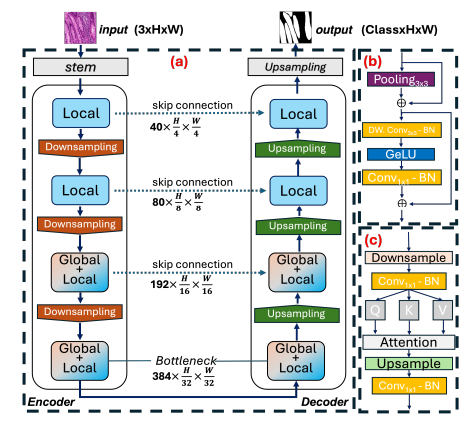

In [3]:
Image(filename='u-arch.png', width=512, height=512)

### Encoder
---

In [4]:
class LocalBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.dw_conv = nn.Conv2d(
            channels, channels,
            kernel_size=3,
            padding=1,
            groups=channels,
            bias=False
        )

        self.pw_conv = nn.Conv2d(
            channels, channels,
            kernel_size=1,
            bias=False
        )

        self.norm = nn.BatchNorm2d(channels)
        self.act = nn.GELU()

    def forward(self, x):
        identity = x

        out = self.dw_conv(x)
        out = self.pw_conv(out)
        out = self.norm(out)
        out = self.act(out)

        return out + identity

In [5]:
class GlobalLocalBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()

        self.norm1 = nn.LayerNorm(channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm2 = nn.BatchNorm2d(channels)

        self.conv = nn.Conv2d(
            channels, channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.act = nn.GELU()

    def forward(self, x):
        B, C, H, W = x.shape
        identity = x


        x_flat = x.flatten(2).transpose(1, 2)
        x_attn = self.norm1(x_flat)
        attn_out, _ = self.attn(x_attn, x_attn, x_attn)
        x_attn = attn_out + x_flat

        x_attn = x_attn.transpose(1, 2).view(B, C, H, W)

        out = self.conv(x_attn)
        out = self.norm2(out)
        out = self.act(out)

        return out + identity

In [6]:
class EncoderStage(nn.Module):
    def __init__(self, in_channels, out_channels, block_type='local', downsample=True):
        super().__init__()

        if downsample:
            self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1, bias=False)
        else:
            self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)

        self.norm = nn.BatchNorm2d(out_channels)
        self.act = nn.GELU()

        if block_type == 'local':
            self.block = LocalBlock(out_channels)
        else:
            self.block = GlobalLocalBlock(out_channels)

    def forward(self, x):
        x = self.conv(x)
        x = self.norm(x)
        x = self.act(x)
        x = self.block(x)
        return x


In [7]:
class Stem(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv = nn.Conv2d(3, out_channels, kernel_size=3, padding=1, bias=False)
        self.norm = nn.BatchNorm2d(out_channels)
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

In [8]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = Stem(64)

        self.stage1 = EncoderStage(64, 64, block_type='local')
        self.stage2 = EncoderStage(64, 128, block_type='local')
        self.stage3 = EncoderStage(128, 256, block_type='global')
        self.stage4 = EncoderStage(256, 512, block_type='global')

    def forward(self, x):
        x = self.stem(x)

        skip1 = self.stage1(x)
        skip2 = self.stage2(skip1)
        skip3 = self.stage3(skip2)
        out   = self.stage4(skip3)

        return out, skip1, skip2, skip3


In [9]:
class Bottleneck(nn.Module):
    def __init__(self, channels, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.block = GlobalLocalBlock(channels)

    def forward(self, x):
        return self.block(x)

### Decoder
---

In [10]:
class DecoderStage(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, block_type='local'):
        super().__init__()

        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.conv = nn.Conv2d(
            in_channels + skip_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.norm = nn.BatchNorm2d(out_channels)
        self.act = nn.GELU()

        if block_type == 'local':
            self.block = LocalBlock(out_channels)
        else:
            self.block = GlobalLocalBlock(out_channels)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        x = self.norm(x)
        x = self.act(x)
        x = self.block(x)
        return x


In [11]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.stage1 = DecoderStage(
            in_channels=512,
            skip_channels=256,
            out_channels=256,
            block_type='global'
        )

        self.stage2 = DecoderStage(
            in_channels=256,
            skip_channels=128,
            out_channels=128,
            block_type='local'
        )

        self.stage3 = DecoderStage(
            in_channels=128,
            skip_channels=64,
            out_channels=64,
            block_type='local'
        )

    def forward(self, x, skip3, skip2, skip1):
        x = self.stage1(x, skip3)
        x = self.stage2(x, skip2)
        x = self.stage3(x, skip1)
        return x


In [12]:
class SegmentationHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.upsample = nn.Upsample(
            scale_factor=2,
            mode='bilinear',
            align_corners=False
        )

        self.conv = nn.Conv2d(
            in_channels,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):
        x = self.upsample(x)
        x = self.conv(x)
        return x


### Model
---

In [13]:
class EViTUNet(nn.Module):
    def __init__(self, num_classes, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.encoder = Encoder()
        self.bottleneck = Bottleneck(512)
        self.decoder = Decoder()
        self.head = SegmentationHead(64, num_classes)

    def forward(self, x):
        x, skip1, skip2, skip3 = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x, skip3, skip2, skip1)
        x = self.head(x)

        return x

##### The forward pass is performed using randomly generated inputs to validate the architectural integrity of the reproduced model, rather than to obtain meaningful segmentation predictions.
---

In [14]:
model = EViTUNet(num_classes=2)
x = torch.randn(1, 3, 224, 224)

y = model(x)
print(y.shape)

torch.Size([1, 2, 224, 224])


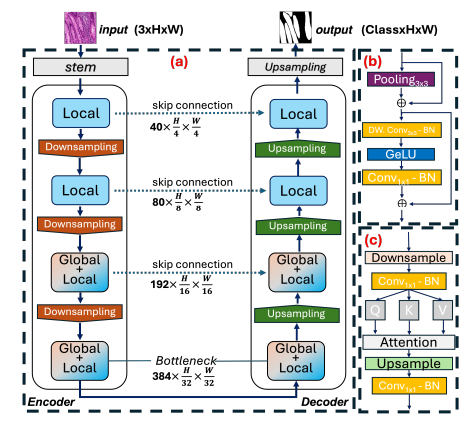

In [15]:
Image(filename='u-arch.png', width=512, height=512)

In [16]:
class LocalBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.pool = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)

        self.dw_conv = nn.Conv2d(
            channels, channels,
            kernel_size=3,
            padding=1,
            groups=channels,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(channels)
        self.act = nn.GELU()

        self.pw_conv = nn.Conv2d(
            channels, channels,
            kernel_size=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        ident = x

        x = self.pool(x)
        x = self.dw_conv(x)
        x = self.bn1(x)
        x = self.act(x)

        x = self.pw_conv(x)
        x = self.bn2(x)

        return x + ident

In [17]:
class GlobalLocalBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()

        # Downsample
        self.down = nn.Conv2d(
            channels, channels,
            kernel_size=3,
            stride=2,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(channels)

        # Self-Attention
        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )

        # Upsample
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        # Projection
        self.proj = nn.Conv2d(
            channels, channels,
            kernel_size=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x

        # Downsample
        x = self.down(x)
        x = self.bn1(x)

        # Attention
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)   # B × HW × C
        x, _ = self.attn(x, x, x)
        x = x.transpose(1, 2).view(B, C, H, W)

        # Upsample + projection
        x = self.up(x)
        x = self.proj(x)
        x = self.bn2(x)

        return x + identity